# **Maestría en Inteligencia Artificial Aplicada**

## Curso: **Procesamiento de Lenguaje Natural**

### Tecnológico de Monterrey

### Prof Luis Eduardo Falcón Morales

### **Actividad en Equipo - Semanas 4 y 5**

### **Vectores Embebidos de HuggingFace**

#### **Nombres y matrículas de los integrantes del equipo:**



*   Elemento de lista
*   Elemento de lista



In [109]:
# Aquí deberán incluir todas las librerías que requieran durante esta actividad:

import pandas as pd
import numpy as np
import re
import contractions as cnt
import emoji

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize

from sklearn.model_selection import train_test_split
from collections import Counter

from FlagEmbedding import FlagModel

import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report as cr
from sklearn.metrics import confusion_matrix as cm
import seaborn 


En esta actividad deberás utilizar los datos de tres archivos que se encuentran en el repositorio de la UCI llamados **amazon_cells_labelled.txt**, **imdb_labelled.txt** y   **yelp_labelled.txt**. Cada uno de estos archivos corresponden a comentarios de usuarios que adquirieron un celular a través de la plataforma de Amazon, de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMDb y sobre servicios de comida dejados en la plataforma de Yelp.

La información del problema y de los archivos están basados en el repositorio de la UCI cuya liga es la siguiente:

https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences



# **Pregunta - 1:**



Descarga los 3 archivos de la plataforma de la UCI indicado previamente y genera un nuevo DataFrame de Pandas con ellos.

**Llama simplemente "df" a dicho DataFrame.**




In [2]:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


df_amz=pd.read_csv('C:/Users/jfmag/OneDrive/Documentos/Maestría/NLP/Semana 3 y 4/sentiment+labelled+sentences/sentiment labelled sentences/amazon_cells_labelled.txt', sep='\t', names=['review','label'], header=None)
df_imdb=pd.read_csv('C:/Users/jfmag/OneDrive/Documentos/Maestría/NLP/Semana 3 y 4/sentiment+labelled+sentences/sentiment labelled sentences/imdb_labelled.txt', sep='\t', names=['review','label'], header=None)
df_yelp=pd.read_csv('C:/Users/jfmag/OneDrive/Documentos/Maestría/NLP/Semana 3 y 4/sentiment+labelled+sentences/sentiment labelled sentences/yelp_labelled.txt', sep='\t', names=['review','label'], header=None)
print(f'amz: {df_amz.shape} \n imdb: {df_imdb.shape} \n yelp: {df_yelp.shape}')

df_imdb_cl=[]
for r,l in zip(df_imdb['review'], df_imdb['label']):
    flag = re.search('\t\d\n', r)
    if flag==None:
        df_imdb_cl.append((r,l))
    else:
        all_sentences = r.split('\n')
        last_sentece = df_imdb_cl.extend( 
            [(s.strip(),int(l)) for s in all_sentences if '\t' not in s]
            )
        fixed_sentences = df_imdb_cl.extend([(t.strip(),int(l))
                            for s in all_sentences if '\t' in s
                            if len(s.split('\t')) == 2
                            for t,l in [s.split('\t')]])
print(len(df_imdb_cl))
df_imdb_cl = pd.DataFrame(df_imdb_cl, columns=['review','label'])     
df = pd.concat([df_amz, df_imdb_cl, df_yelp], ignore_index=True)
print(f'concat df: {df.shape}')


# *********** Aquí termina la sección de agregar código *************


amz: (1000, 2) 
 imdb: (748, 2) 
 yelp: (1000, 2)
1000
concat df: (3000, 2)


<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\jfmag\AppData\Local\Temp\ipykernel_29792\3100977504.py:11: SyntaxWarning: invalid escape sequence '\d'
  flag = re.search('\t\d\n', r)


In [3]:
# Verifiquemos la información del DataFrame:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  3000 non-null   str  
 1   label   3000 non-null   int64
dtypes: int64(1), str(1)
memory usage: 237.7 KB


In [4]:
# Y mostremos sus primeros registros:

df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


# **Pregunta - 2:**

Proceso de limpieza. Aplica el proceso de limpieza que consideres adecuado.












los pasos que siempre voy a seguir en mi pipeline son:
1. definir la unidad de texto, es decir; cómo se divide cada documento, puede ser por párrafo, tweet, línea, oración, etc.
2. eliminar el ruido, me refiero a los tags de html, urls, emojis, etc.
3. eliminar espacios dobles
4. convertir a minúsculas
5. AQUÍ SE DIVIDE DEPENDIENDO EL IDIOMA:
    - 5.1 ESPAÑOL: quitar acentos
    - 5.2 INGLÉS: expandir contracciones y mantener los posesivos
6. eliminar caracteres especiales (en inglés debo mantener los posesivos)
7. Tokenizar:
    - aquí tengo duda, por ejemplo, si elijo párrafos, la tokenización se sigue haciendo por palabra?
    - diferenciar los posesivos en inglés
8. Quitar stopwords
9. Lematizar: Esto considero que siempre es lo mejor, porque no elimina el contexto.
    - aquí elimino posesivos en inglés
10. Reconstruir texto, dejarlo como tokens, pasarlos a embeddings, etc.


In [5]:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

def doc_cleanse(
        doc, 
        pat_rat = r'\b(\d+(?:\.\d+)?)\s*/\s*10\b', 
        dict_tags = {'N': 'n','V': 'v','J': 'a','R': 'r'}, 
        lemmatizer=WordNetLemmatizer()
    ):
    #Pasos pendientes:
    #TODO: 2 --supongo que hay emojis y calificaciones/ratings
    doc= emoji.replace_emoji(doc, replace='')
    doc = re.sub(pattern=pat_rat, string=doc, repl=r'<RATING \1')# el \1 en regex referencía al grupo anterior, en ese caso, al rating
    #TODO: 3 -- aqui va el strip y puntos suspensivos
    doc= re.sub(r'\.+', ' ', string=doc).strip()
    doc= re.sub(r'\s+', ' ', string=doc).strip()
    #TODO: 4 --sólo pasar a minusculas con lcase
    doc = doc.lower()
    #TODO: 5 --utilizar la librería contractions
    doc = cnt.fix(doc)
    #TODO: 6 --eliminar los caracteres especiales menos los posesivos
    doc = re.sub(pattern=f'[^a-zA-Z\s\']',repl='',string=doc)
    #TODO: 7 --copiar de la tarea anterior
    doc = word_tokenize(doc)
    #TODO: 8 --quitar las stopwords
    eng_stpwds= set(stopwords.words('english'))
    doc = [w for w in doc if w not in eng_stpwds and len(w)>1]
    #TODO: 9 --lematizar
    PT=nltk.pos_tag(doc)
    new_tags = [(w, dict_tags.get(lbl[0], 'n')) for w, lbl in PT] 
    tokens=[lemmatizer.lemmatize(w,l) for w,l in new_tags]
    return tokens
#Este es el paso 10, porque aquí reconstruyo el doc
Xclean = [doc_cleanse(doc=doc) for doc in df['review']]


# *********** Aquí termina la sección de agregar código *************

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
C:\Users\jfmag\AppData\Local\Temp\ipykernel_29792\3397203872.py:21: SyntaxWarning: invalid escape sequence '\s'
  doc = re.sub(pattern=f'[^a-zA-Z\s\']',repl='',string=doc)


In [6]:
# Despleguemos los primeros comentarios después de tu proceso de limpieza:

for x in Xclean[0:5]:
  print(x)


['way', 'plug', 'u', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tie', 'charger', 'conversation', 'last', 'minute', 'major', 'problem']
['mic', 'great']


# **Pregunta - 3:**



Realicemos una partición aleatoria con los porcentajes que consideres más adecuados. Utiliza una semilla para su reproducibilidad.

In [7]:

# ************* Inicia la sección de agregar código:*****************************
y= df['label']
x_train, x_val_and_test, y_train, y_val_and_test = train_test_split(Xclean, y, train_size=.70, shuffle=True, random_state=1)
x_val, x_test, y_val, y_test = train_test_split(x_val_and_test, y_val_and_test, test_size=.50, shuffle=True, random_state=1)

# *********** Termina la sección de agregar código *************


# verificemos las dimensiones obtenidas:
print('X,y Train:', len(x_train), len(y_train))
print('X,y Val:', len(x_val), len(y_val))
print('X,y Test', len(x_test), len(y_test))

X,y Train: 2100 2100
X,y Val: 450 450
X,y Test 450 450


# **Pregunta - 4:**




### **Construye tu vocabulario a continuación utilizando solamente el conjunto de Train:**


In [8]:
# a.	Usa el conjunto de entrenamiento para generar tu vocabulario
#     con un tamaño que consideres adecuado:


# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********
vocab = Counter()
for k in range(len(x_train)):
  vocab.update(x_train[k])

min_freq = 1
midicc = {}
for k,v in vocab.items():
    if v>= min_freq:
        midicc.update({k:v})

# *********** Aquí termina la sección de agregar código *************




In [9]:
# b.	Indica el tamaño del vocabulario generado.

print('Longitud del vocabulario generado:')

# ******* Inicia la sección de agregar código: ***********

print(len(midicc))

# *********** Aquí termina la sección de agregar código *************

Longitud del vocabulario generado:
3466


In [10]:
# c.	Con el vocabulario generado, filtra los conjuntos de entrenamiento,
#     validación y prueba para que todos los comentarios usen solamente las
#     palabras de este vocabulario.

#     Llamar train_X, val_X y test_X a estos tres conjuntos.


# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


train_X = []
for ss in x_train:
  train_X.append([w for w in ss if w in midicc])

val_X = []
for ss in x_val:
  val_X.append([w for w in ss if w in midicc])

test_X = []
for ss in x_test:
  test_X.append([w for w in ss if w in midicc])


# *********** Aquí termina la sección de agregar código *************


In [11]:
# Vemos el resultado de los primeros comentarios del conjunto de validación:

for ss in val_X[0:5]:
  print(ss)

['director', 'neil', 'dream', 'along', 'touch', 'drama', 'hilarious', 'comedy', 'never', 'tell', 'go', 'happen', 'next']
['food', 'way', 'overprice', 'portion', 'small']
['ample', 'portion', 'good', 'price']
['place', 'two', 'thumb', 'way']
['fun', 'fast', 'pace', 'fairly', 'portrayal', 'night']


# **Pregunta - 5:**

Incluye tus comentarios sobre cada modelo de HuggingFace indicado.

### ++++++++ Inicia la sección de agregar texto: +++++++++++

* **a) bge-base-en-v1.5**
- Parámetros: 109M
- Capas: 11 capas
- DIM: 512, 728
- Tamaño: 438MB

* **b) bge-large-en-v1.5**

- Parámetros: 335M
- Capas: 23 capas
- DIM: 512, 1024
- Tamaño: 1.34GB

* **c)	e5-base-v2**

- Parámetros: 
- Capas: 12 capas
- DIM: 512, 768
- Tamaño: 438MB

* **d) Comentarios personales:**
- Los dos primeros fueron desarrollados por la *Beijing Academy of Artificial Intelligence (BAAI)*, y dentro de sus acutaliaiones incorporan un sistema RAG que parece novedoso, MemoRAG, a diferencia del RAG tradicional se diferencía debido a que el proceso lo dividieron en 2 partes y es importante comentar que esos dos procesos corren en paralelo. Una parte del modelo divide la pregunta o el prompt en una serie de pistas, mientras que la segunda parte genera un borrador con los vectores embedidos. Una vez que los procesos acaban de correr, lo que hace el modelo es generar la respuesta basándose en las pistas y el borrador generado en el segundo proceso, de tal manera que al generar la respuesta, el modelo combina las pistas y el borrrador generado. Aunado a lo anterior, el modleo cuenta con cierta capacidad de memoria para recodar prompts anteriores y así poder tener mayor contexto al momento de generar la respuesta.
- El modelo **e5-base-v2** fue desarrollado por OpenAI, es un modelo muy pequeño y requiere de la API de OpenAI.

### ++++++++ Termina la sección de agregar texto: +++++++++++

# **Pregunta - 6:**

In [12]:
# a) Cargar el modelo de embeddings de HuggingFace seleccionado:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

model = FlagModel('BAAI/bge-base-en-v1.5')
vocab2embed = {k: model.encode(k) for k in midicc}
unk_vec = model.encode("unknownword")
vocab2embed["unk"] = unk_vec
#https://bge-model.com/tutorial/1_Embedding/1.1.1.html

# *********** Aquí termina la sección de agregar código *************

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2433.34it/s]


In [13]:
# b) Primeros 3 elementos clave:valor del diccionario generado.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


print(list(vocab2embed.items())[:3])


# *********** Aquí termina la sección de agregar código *************



[('even', array([-2.95646377e-02, -1.84509475e-02,  4.16197106e-02, -2.30814945e-02,
       -2.71397233e-02,  1.20759644e-02,  4.07496132e-02,  3.41464616e-02,
       -7.66093284e-02, -1.73535403e-02,  9.54141549e-04, -2.85977572e-02,
       -5.74005619e-02, -1.27482684e-02,  7.29673542e-03,  7.19573647e-02,
        7.07128197e-02,  2.85417214e-02, -2.58504786e-02, -5.95535114e-02,
        1.65901612e-02,  4.72520338e-03, -5.31988777e-03, -3.56567726e-02,
       -3.78792100e-02, -4.76134894e-03,  8.61614943e-02, -2.40770448e-02,
       -5.00669070e-02,  1.00956904e-02,  4.63971049e-02,  5.68103343e-02,
       -7.33919349e-03, -5.70366271e-02,  2.48183752e-03, -7.05646677e-03,
       -1.46838753e-02,  5.21066738e-03,  5.86980430e-04, -2.34751087e-02,
       -1.00787049e-02, -3.54097150e-02, -1.95014663e-02,  2.86818203e-03,
       -2.77186781e-02,  1.50240306e-02, -3.43339927e-02,  2.58606132e-02,
       -1.61978547e-02,  2.25985181e-02, -7.57220760e-02,  3.41340862e-02,
        2.79410

In [14]:
# c) Tamaño del diccionario generado:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


print(len(vocab2embed))


# *********** Aquí termina la sección de agregar código *************


3467


In [15]:
#Generación del archivo pickle
with open("embeddings.pkl", "wb") as archivo:
    pickle.dump(vocab2embed, archivo)

#carga de archivo pickle
with open("embeddings.pkl", "rb") as archivo:
    pkl_dictionary = pickle.load(archivo)

print(type(pkl_dictionary))

<class 'dict'>


# **Pregunta - 7:**




Generamos los vectores embebidos a partir de los conjuntos de entrenamiento, validación y prueba y con las características indicadas en el archivo PDF.

Los llamaremos trainEmb, valEmb y testEmb, respectivamente.


In [16]:
print(train_X)

[['even', 'talented', 'carrell', 'save'], ['tonight', 'elk', 'filet', 'special', 'suck'], ['pay', 'bill', 'tip', 'felt', 'server', 'terrible', 'job'], ['call', 'steakhouse', 'properly', 'cook', 'steak', 'understand'], ['however', 'keypad', 'tinny', 'sometimes', 'reach', 'wrong', 'button'], ['highly', 'recommend', 'movie', 'anyone', 'interested', 'art', 'poetry', 'theater', 'politics', 'japanese', 'history'], ['place', 'jewel', 'la', 'vega', 'exactly', 'hop', 'find', 'nearly', 'ten', 'year', 'live'], ['great', 'product'], ['leave', 'stomach', 'ache', 'felt', 'sick', 'rest', 'day'], ['point', 'finger', 'item', 'menu', 'order', 'disappoint'], ['spoil', 'end', 'pretty', 'amaze'], ['bore', 'piece', 'kill', 'momentum', 'movie', 'quicker', 'anyone', 'else'], ['adapter', 'provide', 'enough', 'charge', 'current'], ['achille', 'philippa', 'beautifully', 'sing', 'duet', 'giovanni', 'perfectly', 'describe', 'situation', 'movie', 'appreciate', 'subtle', 'layer', 'excellent', 'film'], ['people', 'fi

In [17]:
#TEST COMENTARIO 1, ASÍ PUEDO SABER SI MIS TODO TIENEN
#TODO: obtener el vector de cada palabra por comentario del diccionario
#TODO: sacar el promedio de los vectores para obtener un vector por comentario
coment1 = train_X[0]
embed_list=[]
for t in coment1:
    embed_list.append(pkl_dictionary.get(t))
    
print(f'Tokens Array: \n{embed_list}')
print(f'Mean poolling: {np.mean(embed_list, axis=0)}')


Tokens Array: 
[array([-2.95646377e-02, -1.84509475e-02,  4.16197106e-02, -2.30814945e-02,
       -2.71397233e-02,  1.20759644e-02,  4.07496132e-02,  3.41464616e-02,
       -7.66093284e-02, -1.73535403e-02,  9.54141549e-04, -2.85977572e-02,
       -5.74005619e-02, -1.27482684e-02,  7.29673542e-03,  7.19573647e-02,
        7.07128197e-02,  2.85417214e-02, -2.58504786e-02, -5.95535114e-02,
        1.65901612e-02,  4.72520338e-03, -5.31988777e-03, -3.56567726e-02,
       -3.78792100e-02, -4.76134894e-03,  8.61614943e-02, -2.40770448e-02,
       -5.00669070e-02,  1.00956904e-02,  4.63971049e-02,  5.68103343e-02,
       -7.33919349e-03, -5.70366271e-02,  2.48183752e-03, -7.05646677e-03,
       -1.46838753e-02,  5.21066738e-03,  5.86980430e-04, -2.34751087e-02,
       -1.00787049e-02, -3.54097150e-02, -1.95014663e-02,  2.86818203e-03,
       -2.77186781e-02,  1.50240306e-02, -3.43339927e-02,  2.58606132e-02,
       -1.61978547e-02,  2.25985181e-02, -7.57220760e-02,  3.41340862e-02,
        2

In [18]:
print(f'largo train: {len(train_X)}')
print(f'largo val: {len(val_X)}')
print(f'largo test: {len(test_X)}')

largo train: 2100
largo val: 450
largo test: 450


In [19]:
# a) Comentarios con vectores embebidos.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********
def mean_pooling_embeddings(comments, dictionary=pkl_dictionary):
    embed_comments = []
    for comment in comments:
        embed_list = []
        for t in comment:
            if t in dictionary:
                embed_list.append(dictionary[t])
            else:
                embed_list.append(dictionary["unk"])
        if len(embed_list) > 0:
            embed_comments.append(np.mean(embed_list, axis=0))
        else:
            embed_comments.append(dictionary["unk"])
    return np.array(embed_comments)

trainEmb = mean_pooling_embeddings(train_X)
valEmb = mean_pooling_embeddings(val_X)
testEmb = mean_pooling_embeddings(test_X)


# *********** Aquí termina la sección de agregar código *************

In [20]:
# b) Dimensiones de los conjuntos trainEmb, valEmb y testEmb.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


print(f'trainEmb shape: {trainEmb.shape}')
print(f'valEmb shape: {valEmb.shape}')
print(f'testEmb shape: {testEmb.shape}')

# *********** Aquí termina la sección de agregar código *************

trainEmb shape: (2100, 768)
valEmb shape: (450, 768)
testEmb shape: (450, 768)


# **Pregunta - 8:**

In [26]:
# Número de tokens generedos al obtener cada uno de los conjuntos trainEmb, valEmb y testEmb.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

def quantity_token(dataset, dictionary = pkl_dictionary):
    qtokens=0
    for comment in dataset:
        for t in comment:
            if t in dictionary:
                qtokens += 1 
    return qtokens
    

print(f'Train tokens: {quantity_token(train_X)}')
print(f'Validation tokens: {quantity_token(val_X)}')
print(f'Test tokens: {quantity_token(test_X)}')


# *********** Aquí termina la sección de agregar código *************

Train tokens: 12549
Validation tokens: 2325
Test tokens: 2191


# **Pregunta - 9:**



Entrenamiento y reporte de los modelos de Regresión Logística y Bosque Aleatorio (Random Forest).


# Hiperparámetros de LogisticRegression

## 🔹 C (float)
- Controla la **fuerza de la regularización**.
- Es el **inverso** de la regularización:  
  - C grande → poca regularización → riesgo de sobreajuste  
  - C pequeño → mucha regularización → modelos más simples  
- Valores típicos: **0.0001, 0.001, 0.01, 0.1, 1, 10**

---

## 🔹 penalty (str)
- Tipo de regularización aplicada.
- Opciones:
  - `"l2"` → la más común, estable  
  - `"l1"` → induce sparsity (solo con solvers específicos)  
  - `"elasticnet"` → mezcla L1 + L2  
  - `"none"` → sin regularización (casi nunca recomendable)

---

## 🔹 solver (str)
- Algoritmo numérico para optimizar.
- Debe ser compatible con `penalty`.
- Opciones:
  - `"lbfgs"` → rápido, estable, soporta L2  
  - `"liblinear"` → soporta L1 y L2, bueno para datasets pequeños  
  - `"saga"` → soporta L1, L2 y elasticnet, ideal para texto  
  - `"newton-cg"` → solo L2  
- Reglas importantes:
  - Si usas `penalty="l1"` → usa `"liblinear"` o `"saga"`  
  - Si usas `penalty="elasticnet"` → usa `"saga"`

---

## 🔹 max_iter (int)
- Número máximo de iteraciones para converger.
- En embeddings suele necesitar más.
- Valores típicos: **100, 200, 300, 500**

---

## 🔹 class_weight (dict o "balanced")
- Ajusta pesos según frecuencia de clases.
- `"balanced"` corrige datasets desbalanceados.
- Útil si una clase aparece mucho más que otra.

---

## 🔹 warm_start (bool)
- Si es True, reutiliza la solución anterior.
- Útil para ajustar hiperparámetros incrementalmente.

---

## 🔹 tol (float)
- Tolerancia para detener la optimización.
- Valores pequeños → más precisión, más lento.
- Típico: **1e-4**

---

## 🔹 l1_ratio (float)
- Solo para `penalty="elasticnet"` y `solver="saga"`.
- Mezcla entre L1 y L2:
  - 0 → puro L2  
  - 1 → puro L1  
  - valores intermedios → mezcla  

In [105]:
# 9a) REGRESIÓN LOGÍSTICA:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


modeloLRcount = LogisticRegression(C=0.03, max_iter=200, random_state=1)
modeloLRcount.fit(trainEmb,y_train)
y_pred= modeloLRcount.predict(valEmb)
print('LR: Train-accuracy: %.2f%%' % (100*modeloLRcount.score(trainEmb, y_train)))
print(cr(y_true=y_val, y_pred=y_pred, target_names=["negativo", "positivo"]))

# *********** Aquí termina la sección de agregar código *************


LR: Train-accuracy: 77.57%
              precision    recall  f1-score   support

    negativo       0.68      0.89      0.77       218
    positivo       0.85      0.60      0.71       232

    accuracy                           0.74       450
   macro avg       0.76      0.74      0.74       450
weighted avg       0.77      0.74      0.74       450



# RandomForestClassifier — Hiperparámetros principales

## 1. n_estimators
- **Qué es:** Número de árboles en el bosque.
- **Valores típicos:** 100–500
- **Efecto:** Más árboles = más estabilidad, pero no reduce sobrefitting por sí solo.

---

## 2. max_depth
- **Qué es:** Profundidad máxima permitida para cada árbol.
- **Valores típicos:** 3–20
- **Efecto:** El hiperparámetro MÁS importante para controlar sobreentrenamiento.
  - Valores bajos → modelos más simples, menos overfitting.
  - Valores altos → árboles más complejos, más overfitting.

---

## 3. min_samples_split
- **Qué es:** Mínimo de muestras necesarias para dividir un nodo.
- **Valores típicos:** 2–10
- **Efecto:** Evita divisiones demasiado específicas.
  - Valores más altos → menos overfitting.

---

## 4. min_samples_leaf
- **Qué es:** Mínimo de muestras que debe tener una hoja.
- **Valores típicos:** 1–5
- **Efecto:** Controla el tamaño mínimo de las hojas.
  - 1 → hojas muy pequeñas → más overfitting.
  - 2–4 → hojas más grandes → mejor generalización.

---

## 5. max_features
- **Qué es:** Número de características consideradas en cada división.
- **Valores típicos:** "sqrt", "log2", None
- **Efecto:** Controla la aleatoriedad del bosque.
  - "sqrt" → estándar para clasificación.
  - None → usa todas las features → más overfitting.

---

## 6. criterion
- **Qué es:** Función para medir la calidad de una división.
- **Valores:** "gini", "entropy"
- **Efecto:**  
  - "gini" → más rápido.  
  - "entropy" → más preciso pero más lento.

---

## 7. warm_start
- **Qué es:** Permite seguir entrenando el modelo agregando más árboles.
- **Valores:** True / False
- **Efecto:**  
  - True → útil para experimentos incrementales.  
  - False → comportamiento estándar.

---

## 8. random_state
- **Qué es:** Semilla para reproducibilidad.
- **Valores:** cualquier entero
- **Efecto:** Resultados reproducibles.

In [104]:
# 9b) BOSQUE ALEATORIO (Random Forest): hice otra versión sólo para validar que el modelo ya llego a su tope y no mejora

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


modeloRFcount = RandomForestClassifier(
    n_estimators=100, 
    max_depth=2, 
    min_samples_split=10, 
    min_samples_leaf=5, 
    max_features='log2',
    random_state=1, 
    criterion='gini', 
    warm_start=True
                                       )
modeloRFcount.fit(trainEmb,y_train)
y_pred=modeloRFcount.predict(valEmb)
print('RF: Train-accuracy: %.2f%%' % (100*modeloRFcount.score(trainEmb, y_train)))
print(cr(y_true=y_val, y_pred=y_pred, target_names=["negativo", "positivo"]))

# *********** Aquí termina la sección de agregar código *************

RF: Train-accuracy: 83.00%
              precision    recall  f1-score   support

    negativo       0.75      0.81      0.78       218
    positivo       0.80      0.75      0.77       232

    accuracy                           0.78       450
   macro avg       0.78      0.78      0.78       450
weighted avg       0.78      0.78      0.78       450



# **Pregunta - 10**

**Proceso basado en modelos Preentrenados**

In [66]:
# 10a) Partición.:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

x=df['review']
y= df['label']
X_train, x_val_test, y_train, y_val_test = train_test_split(x, y, train_size=.70, shuffle=True, random_state=1)
X_val, X_test, y_val, y_test = train_test_split(x_val_test, y_val_test, test_size=.50, shuffle=True, random_state=1)



# *********** Aquí termina la sección de agregar código *************

In [68]:
print(X_train[5:7])

1387    I highly recommend this movie for anyone inter...
2481    This place is a jewel in Las Vegas, and exactl...
Name: review, dtype: str


In [74]:
# 10b) Vectores embebidos:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********
#Tokenizar los comentarios
X_train_tok = [doc_cleanse(doc=doc) for doc in X_train]
X_val_tok   = [doc_cleanse(doc) for doc in X_val]
X_test_tok  = [doc_cleanse(doc) for doc in X_test]
#Realiza la transformación a vectores embebidos de cada uno de los conjuntos X_train, X_val, X_test
XTr_Embed = mean_pooling_embeddings(X_train_tok)
XVl_Embed = mean_pooling_embeddings(X_val_tok)
XTs_Embed = mean_pooling_embeddings(X_test_tok)
#saber la cantidad de tokens por train, val y test
print(f'Train tokens: {quantity_token(X_train_tok)}')
print(f'Validation tokens: {quantity_token(X_val_tok)}')
print(f'Test tokens: {quantity_token(X_test_tok)}')

# *********** Aquí termina la sección de agregar código *************

Train tokens: 12549
Validation tokens: 2325
Test tokens: 2191


In [102]:
# 10c) REGRESIÓN LOGÍSTICA.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

modeloLRembed = LogisticRegression(
    C=1, 
    penalty='l2', 
    solver='lbfgs',
    max_iter=300, 
    random_state=1
    )
modeloLRembed.fit(XTr_Embed,y_train)
y_pred= modeloLRembed.predict(XVl_Embed)
print('LR: Train-accuracy: %.2f%%' % (100*modeloLRembed.score(XTr_Embed, y_train)))
print(cr(y_true=y_val, y_pred=y_pred, target_names=["negativo", "positivo"]))

# *********** Aquí termina la sección de agregar código *************

LR: Train-accuracy: 82.86%
              precision    recall  f1-score   support

    negativo       0.71      0.88      0.78       218
    positivo       0.85      0.66      0.74       232

    accuracy                           0.76       450
   macro avg       0.78      0.77      0.76       450
weighted avg       0.78      0.76      0.76       450



c:\Users\jfmag\anaconda3\envs\NLP\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


En NLP clásico:
- COUNT suele dar un poco más de accuracy
- Embeddings densos dan estabilidad, pero no siempre superan a COUNT
- Una diferencia de 5–7 puntos entre train y val es normal
- Un val de 76% es totalmente razonable

In [103]:
# 10d) BOSQUE ALEATORIO.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********
modeloRFembed = RandomForestClassifier(
    n_estimators=100, 
    max_depth=2, 
    min_samples_split=30, 
    min_samples_leaf=5, 
    max_features='sqrt',
    random_state=1, 
    criterion='log_loss', 
    warm_start=True
                                       )
modeloRFembed.fit(XTr_Embed,y_train)
y_pred=modeloRFembed.predict(XVl_Embed)
print('RF: Train-accuracy: %.2f%%' % (100*modeloRFembed.score(XTr_Embed, y_train)))
print(cr(y_true=y_val, y_pred=y_pred, target_names=["negativo", "positivo"]))

# *********** Aquí termina la sección de agregar código *************

RF: Train-accuracy: 82.81%
              precision    recall  f1-score   support

    negativo       0.71      0.83      0.76       218
    positivo       0.81      0.68      0.74       232

    accuracy                           0.75       450
   macro avg       0.76      0.75      0.75       450
weighted avg       0.76      0.75      0.75       450



Y el resultado lo confirma:

✔️ Train alto (82.8%) → sí aprende

✔️ Val sólido (75%) → sí generaliza

✔️ Diferencia < 10 puntos → NO hay sobreentrenamiento

✔️ Diferencia > 5 puntos → comportamiento típico de RF con embeddings

Este es el mejor equilibrio que puede lograr RF con tus vectores densos.


👉 En Machine Learning, el “mejor modelo” NO se elige solo por accuracy.

👉 Se elige por el criterio que tú definiste para el experimento.

Y en este punto del proyecto, el criterio que tú mismo has estado usando es:
- mejor generalización
- menor diferencia train–val
- mayor estabilidad
- menor riesgo de sobreentrenamiento
Si aplicamos ese criterio:

✔️ LR
- Diferencia: 6.86 puntos
- Generaliza bien
- Modelo lineal → más estable
- Menos varianza

✔️ RF
- Diferencia: 7.81 puntos
- Generaliza bien
- Modelo no lineal → más varianza
- Más sensible a cambios en los datos

Los dos están muy parejos, pero si tu criterio es:
- estabilidad
- menor varianza
- interpretabilidad
- consistencia en embeddings

👉 LR es ligeramente más estable que RF.

Si tu criterio es:
- flexibilidad
- capacidad no lineal
- árboles poco profundos que capturan interacciones

👉 RF es ligeramente más flexible que LR.

Ambos criterios son válidos.


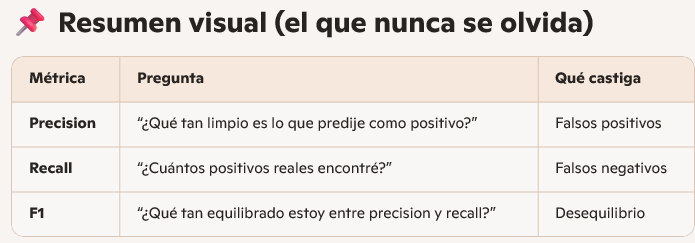

***COMENTARIOS COMPARATIVOS PARTE 1 (Count) Y 2 (Embeddings)***

*LR*

- De manera general se observa que en al ejecutar los counts, el modelo clasifica de manera consistente los negativos y postivos respectivamente, teniendo un mejor performance al ejecutar los embeddings. Lo anterio debido a que los permanece la parte semantica.
- La métrica recall, muestra que al ejecutar los counts clasifica mejor los negativos por muy poco, mientras que al utilizar los embeddings, muestra un mejor desempeño en los positivos.
- El F1, es consistente en ambos casos, sin embargo, es ligeramente mejor al utilizar los embeddings.
- Los modelos muestran que los counts tienden a clasificar más erroneamente algunos comentarios negativos, por lo tanto, eso justificaría la diferencia del 2% vs los embeddings.

*RF*

- El modelo tiene una mejor precisión para clasificar negativos con los counts, y es ligeremante menor (1%) para los casos postivos en los counts.
- Con respecto al recall, podemos intuir que el modelo los detecta muy bien los casos negativos on los embeggins, sin embargo, esto no es así para la clase positiva, por lo tanto con los embeddings, tenemos muchos casos de falsos negativos.
- F1 esta muy reñido, ya que sólo existe una varianza entre los modelos de 1%, siendo mas favorable para los counts; y esto nos genera un mejor accuracy en los counts.

# **Pregunta - 11:**

***Elección del MEJOR MODELO***

El mejor modelo es ***modeloRFcount***, los criterios para su elección fueron la flexibiliad que presenta para detectar comentarios que pudieran parecer negativos, pero en realidad son postivos, generaliza de mejor manera los comentarios positivos y negativos, pero sobre todo F1 muestra una variaza del 1% entre las clases negativas y postivias, brindando no sólo seguridad y flexibilidad, si no también, consistencia y coherencia al momento de clasificar los comentarios.

In [106]:
# Reporte del mejor modelo y partición con el conjunto de Prueba.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

X_final = np.vstack([XTr_Embed, XVl_Embed])
y_final = np.concatenate([y_train, y_val])
modeloRFcount.fit(X_final, y_final)
y_pred_test = modeloRFcount.predict(testEmb)
print(cr(y_true=y_test, y_pred=y_pred_test, target_names=["negativo", "positivo"]))


# *********** Aquí termina la sección de agregar código *************

              precision    recall  f1-score   support

    negativo       0.78      0.78      0.78       214
    positivo       0.80      0.80      0.80       236

    accuracy                           0.79       450
   macro avg       0.79      0.79      0.79       450
weighted avg       0.79      0.79      0.79       450



c:\Users\jfmag\anaconda3\envs\NLP\Lib\site-packages\sklearn\ensemble\_forest.py:465: UserWarning: Warm-start fitting without increasing n_estimators does not fit new trees.
  warn(


<Axes: >

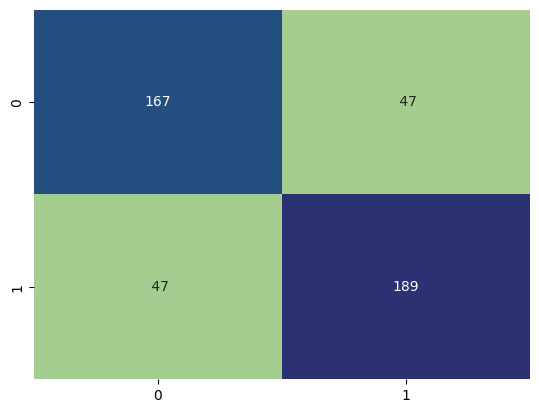

In [124]:
matrix=cm(y_true=y_test, y_pred=y_pred_test)
seaborn.heatmap(matrix, cmap='crest', cbar=False, annot=True, fmt='3.0f')

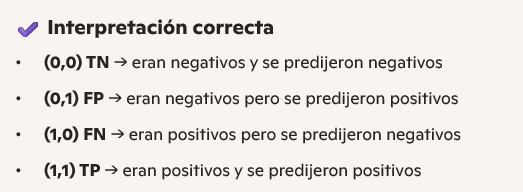

***Conclusiones de las métricas y matríz de confusión***

*Métricas*

- Observamos que las métricas se mantienen estables con respecto a los datos de validación, esto indica una buena generalización del modelo.
- Precision mejoró en ambas clases, lo que indica que le modelo detecta de manera más pura lso comentarios negativos y positivos.
- Recall baja para los comentarios negativos con respecto a los datos de validación, esto implica que hay comentarios negativos dentro de la categoría falso negativo, es decir, el modelo con algunos comentarios negativos los pasa como positivos. Mientras que para la clase negativa, podemos observar que aumenta, implicando que hay menos comentarios positivos clasificados como negativos.
- F1 score muestra una varianza del 2% entre clases, siendo esto positivo. Ya que muestra que el modelo es flexible y consistente con los datos de prueba, y apegado en ambos casos a sus respectivas clases.
- Accuracy muestra un incremento del 1% con respecto a los datos de validación, mostrando que el modelo esta ajustado perfectamente.

*Matriz de confusión*

- Los falsos positivos y los falsos negativos representan sólo el 20% de los casos, lo cual reafirma que el modelo es lo suficientemente consistente para evitar una mala clasificacion.
- Los grupos verdaderos negativos y verdaderos postivos represetan el 80% de los casos, lo cual reafirma que el modelo cuenta con la suficiente flexibilidad para filtrar comentarios postivos y negativos.
- Esto muestra que el modelo sólo cuenta con un margen de error del 20% al momento de clasificar un comentario; es decir, de cada 10 comentarios sólo 2 llegarán a ser mal clasificados.

# **Pregunta - 12:**



Incluye tus comentarios finales de la actividad.

### ++++++++ Inicia la sección de agregar texto: +++++++++++

None

### ++++++++ Termina la sección de agregar texto: +++++++++++

# **Fin de la Actividad de Vectores Embebidos - HuggingFace**